# Poisson PINN

Comparison of three PDE residual losses:

1. MSE
2. SINOS
3. D-SINOS

In [1]:
import copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from dd_discretization import DomainDecompositionDiscretization

In [2]:
# Reproducibility and device
SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)

# CPU is intentional: direct dense solves are more stable here.
device = torch.device("cpu")
dtype = torch.float64

print("device:", device)
print("dtype:", dtype)

device: cpu
dtype: torch.float64


## Problem

### Asymmetric nonzero-boundary test function

To test a less symmetric setting with nonzero boundary values, we use the manufactured solution
$$
u(x,y)
=
\alpha_{\exp} e^{a x + b y}
+
\alpha_{\mathrm{osc}} \sin(k_x x + k_y y)
+
\alpha_{\mathrm{poly}} xy
+
\ell_x x
+
\ell_y y ,
$$
with parameters
$$
\alpha_{\exp}=0.25,\qquad
\alpha_{\mathrm{osc}}=0.20,\qquad
\alpha_{\mathrm{poly}}=0.15,
$$
$$
\ell_x=0.10,\qquad
\ell_y=-0.20,
$$
and
$$
a=2.0,\qquad b=-0.75,\qquad k_x=8.0,\qquad k_y=2.0.
$$

This choice combines an anisotropic exponential component, an oscillatory component with different frequencies in the two coordinate directions, a mixed polynomial term, and a linear contribution. In particular, the solution is not symmetric with respect to the coordinate axes and does not vanish on the boundary.

For the Poisson equation
$$
\Delta u = f
$$
on the computational domain, the corresponding right-hand side is
$$
f(x,y)
=
\alpha_{\exp}(a^2+b^2)e^{a x+b y}
-
\alpha_{\mathrm{osc}}(k_x^2+k_y^2)\sin(k_x x+k_y y).
$$
The mixed polynomial term $xy$ and the linear terms have zero Laplacian and therefore do not contribute to $f$.

In [3]:
EXP_AMP = 0.25
OSC_AMP = 0.20
POLY_AMP = 0.15
LIN_X = 0.10
LIN_Y = -0.20

a = 2.0
b = -0.75

kx = 8.0
ky = 2.0


def exact_u(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    exp_part = EXP_AMP * torch.exp(a * x1 + b * x2)
    osc_part = OSC_AMP * torch.sin(kx * x1 + ky * x2)
    poly_part = POLY_AMP * x1 * x2
    lin_part = LIN_X * x1 + LIN_Y * x2

    return exp_part + osc_part + poly_part + lin_part


def rhs_f(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    exp_part_lap = (
        EXP_AMP
        * (a**2 + b**2)
        * torch.exp(a * x1 + b * x2)
    )

    osc_part_lap = (
        -OSC_AMP
        * (kx**2 + ky**2)
        * torch.sin(kx * x1 + ky * x2)
    )

    # Laplacian of x*y and linear terms is zero.
    return exp_part_lap + osc_part_lap

## Discretization grid

In [4]:
# Polynomial degrees for the Gauss--Legendre tensor grid
nx, ny = 10, 10

# Number of cells in x/y direction
rx, ry = 5, 5

nbc = 2 * ry * (ny + 1) + 2 * rx * (nx + 1)

disc = DomainDecompositionDiscretization(
    polynomial_degrees=(nx, ny),
    cells_per_dim=(rx, ry),
    domain=[(-1.0, 1.0), (-1.0, 1.0)],
)
disc.init_boundary_quadrature()

pde_points = disc.points

assert pde_points.shape == (disc.N, 2)

X_pde = torch.as_tensor(pde_points, device=device, dtype=dtype)
X_bc = torch.as_tensor(disc.X_bc, device=device, dtype=dtype)
u_bc = exact_u(X_bc).detach()

W_bc = torch.as_tensor(disc.W_bc, device=device, dtype=dtype)
W = torch.as_tensor(disc.W, device=device, dtype=dtype)
Hmat_pinv = torch.as_tensor(disc.Hmat_pinv, device=device, dtype=dtype)
Hmat_pinv_s = torch.as_tensor(disc.Hmat_s_pinv, device=device, dtype=dtype)

## Network

In [5]:
class SinePINN(torch.nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = torch.nn.ModuleList(
            [torch.nn.Linear(layers[i], layers[i + 1]) for i in range(len(layers) - 1)]
        )
        self.reset_parameters()

    def reset_parameters(self):
        for layer in self.layers:
            torch.nn.init.xavier_uniform_(layer.weight)
            torch.nn.init.zeros_(layer.bias)

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = torch.sin(layer(x))
        return self.layers[-1](x)


def make_model():
    return SinePINN([2, 50, 50, 50, 50, 50, 1]).to(device=device, dtype=dtype)

## PDE residual

In [6]:
def poisson_residual(model, x):
    x = x.detach().clone().requires_grad_(True)
    u = model(x)

    grad_u = torch.autograd.grad(
        u,
        x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
    )[0]

    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]

    u_xx = torch.autograd.grad(
        u_x,
        x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
    )[0][:, 0:1]

    u_yy = torch.autograd.grad(
        u_y,
        x,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True,
    )[0][:, 1:2]

    return u_xx + u_yy - rhs_f(x)

## Losses

Here, we use the directo method for SINOS and D-SINOS:

$$
    r^T W H^{-1} r.
$$

In [7]:
def bc_loss_mse(bc_residual):
    return torch.mean(bc_residual**2)


def pde_loss_mse(r):
    return (r.T @ W @ r).squeeze()


def bc_loss_l2(bc_residual):
    return (bc_residual.T @ W_bc @ bc_residual).squeeze()


def negative_loss(mat, name):
    def loss(r):
        value = (r.T @ W @ (mat @ r)).squeeze()
        return torch.clamp(value, min=0.0)

    loss.__name__ = name
    return loss


pde_loss_sinos = negative_loss(Hmat_pinv, "pde_loss_sinos")
pde_loss_dsinos = negative_loss(Hmat_pinv_s, "pde_loss_dsinos")

In [8]:
def compute_losses(
    model,
    pde_loss_from_residual,
    bc_loss_from_residual,
    bc_weight=1.0,
):
    pde_loss = pde_loss_from_residual(poisson_residual(model, X_pde))

    bc_residual = model(X_bc) - u_bc
    bc_loss = bc_loss_from_residual(bc_residual)

    total_loss = pde_loss + bc_weight * bc_loss

    return total_loss, pde_loss, bc_loss

## Evaluate solution

In [9]:
def evaluate_solution(model=None, n_eval=201):
    grid = torch.linspace(-1.0, 1.0, n_eval, device=device, dtype=dtype)

    X, Y = torch.meshgrid(grid, grid, indexing="ij")
    XY = torch.column_stack((X.reshape(-1), Y.reshape(-1)))
    
    with torch.no_grad():
        u_true = exact_u(XY).reshape(n_eval, n_eval)

        if model is not None:
            u_pred = model(XY).reshape(n_eval, n_eval)
            error = u_true - u_pred
            abs_error = torch.abs(error)

            mse = torch.mean(error**2)
            rmse = torch.sqrt(mse)
            max_error = torch.max(abs_error)

            return {
                "prediction": u_pred.detach().cpu().numpy(),
                "error": error.detach().cpu().numpy(),
                "mse": float(mse.detach().cpu()),
                "rmse": float(rmse.detach().cpu()),
                "max_error": float(max_error.detach().cpu()),
            }

    return None

## Training

In [10]:
def train_lbfgs(
    method_name,
    pde_loss_from_residual,
    bc_loss_from_residual,
    base_state,
    n_iter,
    bc_weight=1.0,
    line_search_fn="strong_wolfe",
    print_every=100,
):
    model = make_model()
    model.load_state_dict(copy.deepcopy(base_state))

    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=n_iter,
        max_eval=5 * n_iter,
        history_size=50,
        line_search_fn=line_search_fn,
        tolerance_grad=1e-10,
        tolerance_change=1e-12,
    )

    history = []
    closure_calls = 0

    def make_row(closure_call):
        total_loss, pde_loss, bc_loss = compute_losses(
            model,
            pde_loss_from_residual,
            bc_loss_from_residual,
            bc_weight=bc_weight,
        )

        eval_result = evaluate_solution(model)
        row = {
            "method": method_name,
            "n_iter": n_iter,
            "closure_call": closure_call,
            "total_loss": total_loss.detach().item(),
            "pde_loss": pde_loss.detach().item(),
            "bc_loss": bc_loss.detach().item(),
            "mse": eval_result["mse"],
            "rmse": eval_result["rmse"],
            "max_error": eval_result["max_error"],
        }

        return total_loss, row

    def print_row(row):
        print(
            f"{method_name:8s} | "
            f"closure {row['closure_call']:04d} | "
            f"loss {row['total_loss']:.3e} | "
            f"pde {row['pde_loss']:.3e} | "
            f"bc {row['bc_loss']:.3e} | "
            f"rmse {row['rmse']:.3e} | "
            f"rmse {row['max_error']:.3e}"
        )

    def closure():
        nonlocal closure_calls
        closure_calls += 1

        optimizer.zero_grad(set_to_none=True)

        total_loss, row = make_row(closure_calls)
        total_loss.backward()

        history.append(row)

        if print_every and closure_calls % print_every == 0:
            print_row(row)

        return total_loss

    optimizer.step(closure)

    return model, pd.DataFrame(history)

In [11]:
N_ITER = 5_000

base_model = make_model()
base_state = copy.deepcopy(base_model.state_dict())

model_mse, hist_mse = train_lbfgs(
    "MSE",
    pde_loss_mse,
    bc_loss_mse,
    base_state,
    n_iter=N_ITER,
    bc_weight=1.0,
)

model_sinos, hist_sinos = train_lbfgs(
    "SINOS",
    pde_loss_sinos,
    bc_loss_l2,
    base_state,
    n_iter=N_ITER,
    bc_weight=1.0, # np.sqrt(nbc)
)

model_dsinos, hist_dsinos = train_lbfgs(
    "D-SINOS",
    pde_loss_dsinos,
    bc_loss_l2,
    base_state,
    n_iter=N_ITER,
    bc_weight=1.0, # np.sqrt(nbc)
)

hist = pd.concat(
    [hist_mse, hist_sinos, hist_dsinos],
    ignore_index=True,
)

MSE      | closure 0100 | loss 1.297e+01 | pde 9.605e+00 | bc 3.366e+00 | rmse 1.232e+00 | rmse 5.223e+00
MSE      | closure 0200 | loss 2.162e+00 | pde 1.362e+00 | bc 7.999e-01 | rmse 5.137e-01 | rmse 2.728e+00
MSE      | closure 0300 | loss 5.253e-01 | pde 2.858e-01 | bc 2.395e-01 | rmse 2.798e-01 | rmse 1.165e+00
MSE      | closure 0400 | loss 1.688e-01 | pde 1.206e-01 | bc 4.821e-02 | rmse 1.313e-01 | rmse 4.893e-01
MSE      | closure 0500 | loss 2.820e-02 | pde 2.215e-02 | bc 6.050e-03 | rmse 4.452e-02 | rmse 1.461e-01
MSE      | closure 0600 | loss 8.650e-03 | pde 7.358e-03 | bc 1.292e-03 | rmse 1.992e-02 | rmse 9.800e-02
MSE      | closure 0700 | loss 5.220e-03 | pde 4.116e-03 | bc 1.104e-03 | rmse 1.771e-02 | rmse 9.158e-02
MSE      | closure 0800 | loss 3.974e-03 | pde 2.993e-03 | bc 9.819e-04 | rmse 1.539e-02 | rmse 8.047e-02
MSE      | closure 0900 | loss 3.276e-03 | pde 2.325e-03 | bc 9.516e-04 | rmse 1.534e-02 | rmse 6.836e-02
MSE      | closure 1000 | loss 2.551e-03 | pde

## Benchmark summary

In [12]:
hist = pd.concat(
    [hist_mse, hist_sinos, hist_dsinos],
    ignore_index=True,
)
hist.to_csv(f"results/poisson_pinn/history.csv", index=True)

hist_result = pd.DataFrame(
    [
        hist_mse.iloc[-1],
        hist_sinos.iloc[-1],
        hist_dsinos.iloc[-1],
    ],
    index=["MSE", "SINOS", "D-SINOS"],
)[
    [
        "total_loss",
        "pde_loss",
        "bc_loss",
        "mse",
        "rmse",
        "max_error",
    ]
]

hist_result.style.format("{:.3e}")

,total_loss,pde_loss,bc_loss,mse,rmse,max_error
MSE,9.650e-05,8.947e-05,7.034e-06,1.577e-06,1.256e-03,5.537e-03
SINOS,1.152e-05,9.405e-06,2.118e-06,6.047e-08,2.459e-04,1.304e-03
D-SINOS,1.422e-06,1.214e-06,2.081e-07,1.335e-08,1.155e-04,5.330e-04


## Plots

In [13]:
method_order = ["MSE", "SINOS", "D-SINOS"]

plt.rcParams.update(
    {
        # Figure size / resolution
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        # Fonts
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        # Lines
        "lines.linewidth": 1.5,
        "lines.markersize": 4,
        # Axes
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        # Ticks
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
        # Legend
        "legend.frameon": False,
        # Better PDF/PS font embedding
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

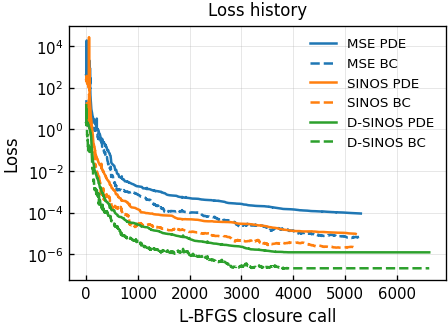

In [28]:
fig, ax = plt.subplots(figsize=(4, 3))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, method in enumerate(method_order):
    df = hist[hist["method"] == method]
    color = colors[i % len(colors)]

    # PDE loss: solid line
    ax.plot(
        df["closure_call"],
        df["pde_loss"],
        color=color,
        linestyle="-",
        label=f"{method} PDE",
    )

    # Boundary loss: dashed line
    ax.plot(
        df["closure_call"],
        df["bc_loss"],
        color=color,
        linestyle="--",
        label=f"{method} BC",
    )

ax.set_yscale("log")
ax.set_xlabel("L-BFGS closure call")
ax.set_ylabel("Loss")
ax.set_title("Loss history")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig("results/poisson_pinn/loss_history.pdf", format="pdf", bbox_inches="tight", dpi=600)
plt.show()

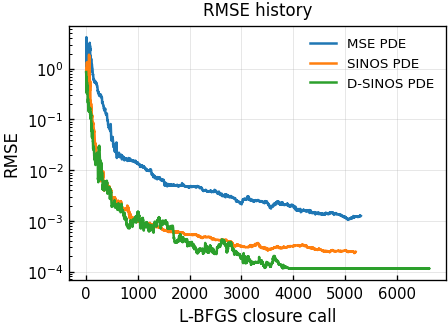

In [27]:
fig, ax = plt.subplots(figsize=(4, 3))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, method in enumerate(method_order):
    df = hist[hist["method"] == method]
    color = colors[i % len(colors)]

    # PDE RMSE
    ax.plot(
        df["closure_call"],
        df["rmse"],
        color=color,
        linestyle="-",
        label=f"{method} PDE",
    )

ax.set_yscale("log")
ax.set_xlabel("L-BFGS closure call")
ax.set_ylabel("RMSE")
ax.set_title("RMSE history")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig("results/poisson_pinn/rmse_history.pdf", format="pdf", bbox_inches="tight", dpi=600)
plt.show()

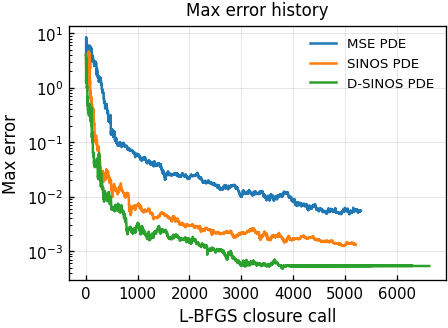

In [26]:
fig, ax = plt.subplots(figsize=(4, 3))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i, method in enumerate(method_order):
    df = hist[hist["method"] == method]
    color = colors[i % len(colors)]

    # PDE RMSE
    ax.plot(
        df["closure_call"],
        df["max_error"],
        color=color,
        linestyle="-",
        label=f"{method} PDE",
    )

ax.set_yscale("log")
ax.set_xlabel("L-BFGS closure call")
ax.set_ylabel("Max error")
ax.set_title("Max error history")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig("results/poisson_pinn/max_error_history.pdf", format="pdf", bbox_inches="tight", dpi=600)
plt.show()

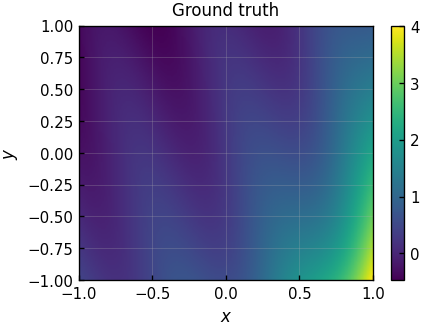

In [25]:
def plot_ground_truth(n_eval=201):
    grid = torch.linspace(-1.0, 1.0, n_eval, device=device, dtype=dtype)

    X, Y = torch.meshgrid(grid, grid, indexing="ij")
    XY = torch.column_stack((X.reshape(-1), Y.reshape(-1)))

    with torch.no_grad():
        u_true = exact_u(XY).reshape(n_eval, n_eval)

    plt.figure(figsize=(4, 3))

    im = plt.imshow(
        u_true.T,
        extent=[-1, 1, -1, 1],
        origin="lower",
        aspect="auto",
    )

    plt.title("Ground truth")
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.colorbar(im)
    plt.tight_layout()
    fig.savefig("results/poisson_pinn/ground_truth.pdf", format="pdf", bbox_inches="tight", dpi=600)
    plt.show()

plot_ground_truth()

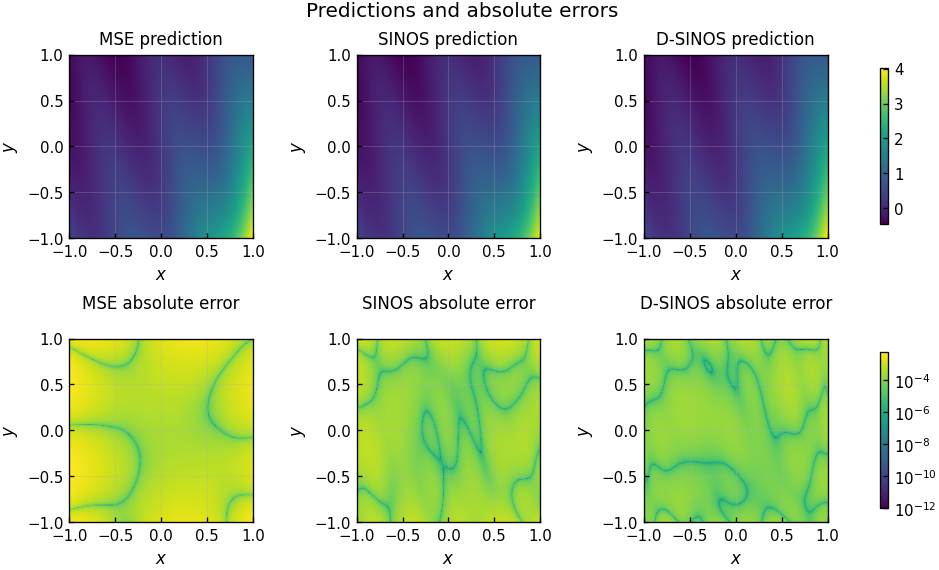

In [24]:
def plot_predictions_and_errors(eval_mse, eval_sinos, eval_dsinos, eps=1e-12):
    items = [
        ("MSE", eval_mse),
        ("SINOS", eval_sinos),
        ("D-SINOS", eval_dsinos),
    ]

    # shared color scale for predictions
    vmin_u = min(np.min(result["prediction"]) for _, result in items)
    vmax_u = max(np.max(result["prediction"]) for _, result in items)

    # shared color scale for absolute errors
    vmax_err = max(np.max(np.abs(result["error"])) for _, result in items)
    vmax_err = max(eps, vmax_err)

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(8.0, 4.8),
        constrained_layout=True,
    )

    # predictions
    pred_im = None

    for j, (label, result) in enumerate(items):
        ax = axes[0, j]

        pred_im = ax.imshow(
            result["prediction"].T,
            extent=[-1, 1, -1, 1],
            origin="lower",
            aspect="equal",
            vmin=vmin_u,
            vmax=vmax_u,
        )

        ax.set_title(f"{label} prediction")
        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")

    fig.colorbar(pred_im, ax=axes[0, :], shrink=0.85)

    err_im = None

    for j, (label, result) in enumerate(items):
        ax = axes[1, j]

        error = result["error"]
        abs_error = np.maximum(np.abs(error), eps)

        err_im = ax.imshow(
            abs_error.T,
            extent=[-1, 1, -1, 1],
            origin="lower",
            aspect="equal",
            norm=LogNorm(vmin=eps, vmax=vmax_err),
        )

        ax.set_title(f"{label} absolute error\n")
        ax.set_xlabel("$x$")
        ax.set_ylabel("$y$")

    fig.colorbar(err_im, ax=axes[1, :], shrink=0.85)

    fig.suptitle("Predictions and absolute errors")
    fig.savefig("results/poisson_pinn/predictions_and_absolute_errors.pdf", format="pdf", bbox_inches="tight", dpi=600)
    plt.show()


eval_mse = evaluate_solution(model_mse)
eval_sinos = evaluate_solution(model_sinos)
eval_dsinos = evaluate_solution(model_dsinos)

plot_predictions_and_errors(eval_mse, eval_sinos, eval_dsinos)